# Исследование профиля нелояльных клиентов банка «Метанпром»

## Цель и задачи  

**Цель:** Провести исследовательский анализ данных клиентов банка «Метанпром» с выявлением портрета клиентов, которые склонны уходить из банка.   

**Задачи:**
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить взаимосвязь данных в столбце `Сhurn` с другими данными.
4. Сформулировать выводы по проведённому анализу.


## Данные

Для анализа поступили данные о клиентах банка «Метанпром». Данные состоят из двух датасетов:

- `bank_information.csv` — информация об использовании клиентом услуг банка;
- `clients_information.csv` —  персональная информация клиентов.

### Описание датасета `bank_information`

- `userid` — идентификатор клиента;
- `score` — баллы кредитного скоринга;
- `Objects` — количество объектов в собственности клиента;
- `Balance` — баланс на счёте клиента;
- `Products` — количество продуктов, которыми пользуется клиент;
- `CreditCard` — есть ли у клиента кредитная карта;
- `Loyalty` — считается ли клиент активным;
- `estimated_salary` — заработная плата клиента;
- `Churn` — ушёл ли клиент из банка.

### Описание датасета `clients_information`

- `userid` — идентификатор клиента;
- `LastName` — фамилия клиента;
- `FirstName` — имя клиента;
- `City` — город обращения в банк;
- `Gender` — пол;
- `Age` — возраст.


## Структура проекта

1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.

---

## Загрузка данных и знакомство с ними

Начнём с загрузки библиотек и датасетов `bank_information` и `clients_information`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik_matrix для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `bank_df` и `clients_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные bank_df и clients_df
bank_df = pd.read_csv('https://code.s3.yandex.net/datasets/bank_information.csv')
clients_df = pd.read_csv('https://code.s3.yandex.net/datasets/clients_information.csv')

Познакомимся с данными датасета `bank_information.csv` — выведем первые строки методом `head()`, а информацию о датафрейме методом `info()`:

In [3]:
# Выводим первые строки датафрейма на экран
bank_df.head()

,userid,score,Objects,Balance,Products,CreditCard,Loyalty,estimated_salary,Churn
0,15677338,619,2,NaN,1,1,1,101348.88,1
1,15690047,608,1,83807.86,1,0,1,112542.58,0
2,15662040,502,8,159660.80,3,1,0,113931.57,1
3,15744090,699,1,NaN,2,0,0,93826.63,0
4,15780624,850,2,125510.82,1,1,1,79084.10,0


In [4]:
# Выводим информацию о датафрейме
bank_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int64  
 2   Objects           10000 non-null  int64  
 3   Balance           6383 non-null   float64
 4   Products          10000 non-null  int64  
 5   CreditCard        10000 non-null  int64  
 6   Loyalty           10000 non-null  int64  
 7   estimated_salary  10000 non-null  float64
 8   Churn             10000 non-null  int64  
dtypes: float64(2), int64(7)
memory usage: 703.2 KB


Датасет `bank_information.csv` содержит 9 столбцов и 10000 строк, в которых представлена информация об использовании клиентами услуг банка.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов лучше привести к одному виду, например snake case.
- Все представленные данные содержат числовые значения и хранятся в типах данных `int64` или `float64`. Значения в столбцах `score`, `Objects`, `Products`, `CreditCard`, `Loyalty` и `Churn` представлены целыми числами. Часть их них показывает наличие у клиента того или иного признака и содержит значения 1 или 0 — размерность этих данных можно оптимизировать.
- Пропуски содержатся только в столбце `Balance`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

Теперь познакомимся с данными датасета `clients_information.csv`.

In [5]:
# Выводим первые строки датафрейма на экран
clients_df.head()

,userid,LastName,FirstName,Age,Gender,City
0,15677338,Лапина,Евпраксия,42,Ж,Ярославль
1,15690047,Александрова,Акулина,41,Ж,Рыбинск
2,15662040,Лаврентьева,Анна,42,Ж,Ярославль
3,15744090,Никитина,Олимпиада,39,Ж,Ярославль
4,15780624,Некрасова,Майя,43,Ж,Рыбинск


In [6]:
# Выводим информацию о датафрейме
clients_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userid     10000 non-null  int64 
 1   LastName   10000 non-null  object
 2   FirstName  10000 non-null  object
 3   Age        10000 non-null  int64 
 4   Gender     10000 non-null  object
 5   City       10000 non-null  object
dtypes: int64(2), object(4)
memory usage: 468.9+ KB


Датасет `clients_information.csv` содержит 6 столбцов и 10000 строк, в которых представлена информация о клиентах банка. По аналогии с предыдущим датасетом можно отметить, что:

- Названия столбцов лучше привести к единому виду, например snake case.
- Типы данных соответствуют содержимому. Тип данных для столбца `Age` можно оптимизировать с понижением размерности. Маловероятно, что он хранит сильно завышенные значения.
- Пропусков на первый взгляд нет, однако следует проверить в столбцах значения-индикаторы, которые могут говорить об отсутствии данных.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные хорошего качества — в них практически нет пропущенных значений, а сами данные соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.

---

## Предобработка данных

### Меняем названия, или метки, столбцов датафрейма

Для переименования используем метод `rename()`, которому передадим словарь с новыми названиями столбцов. Однако сначала выведем все названия на экран — так будет удобнее составлять словарь.

In [7]:
# Выводим названия столбцов датафрейма bank_df
bank_df.columns

Index(['userid', 'score', 'Objects', 'Balance', 'Products', 'CreditCard',
       'Loyalty', 'estimated_salary', 'Churn'],
      dtype='object')

In [8]:
# Передаём методу rename() словарь с названиями столбцов
bank_df = bank_df.rename(columns={'userid': 'userid',
                                  'Objects': 'objects',
                                  'Balance': 'balance',
                                  'Products': 'products',
                                  'CreditCard': 'credit_card',
                                  'Loyalty': 'loyalty',
                                  'Churn': 'churn'})

В названиях столбцов мы поменяли стиль и исправили так называемый CamelCase. При CamelCase (англ. «верблюжий регистр») каждое слово начинается с большой буквы, а между словами нет пробелов и других символов.

Чтобы из CamelCase перейти в snake_case, необходимо все заглавные символы сделать строчными, а между словами добавить подчёркивание `_`. Напишем такую функцию:

In [9]:
# Напишем функцию для корректировки названия столбцов из CamelCase в snake_case
def col_to_snake_case(df):
    """
    Функция приводит названия столбцов из CamelCase в snake_case.
    Пример: столбец FirstName станет first_name.
    В качестве аргументов принимает датафрейм.
    Перебирает столбцы и проверяет каждый столбец.
    Если первый символ является заглавной буквой, то он меняется на прописную.
    Если в названии отыскиваются другие заглавные буквы, перед ними вставляется символ
    подчёркивания, и буква меняется на прописную.
    Функция возвращает исправленный датафрейм.
    """

    for col in df.columns:
        str_bad = col
        if str_bad[0].isupper():
            str_bad = str_bad[0].lower() + str_bad[1:]
        for index_s, item_s in enumerate(str_bad):
            if item_s.isupper():
                str_bad = str_bad[:index_s] + '_' + str_bad[index_s].lower() + str_bad[index_s + 1:]
        df = df.rename(columns={col: str_bad})
    return df

В качестве аргумента функция принимает датафрейм. Она перебирает все значения `df.columns`, то есть названия столбцов. Условие  `if str_bad[0].isupper()` проверяет, является ли первая буква названия заглавной. Если да, то её регистр поменяется. Затем перебираются все символы названия столбца `for index_s, item_s in enumerate(str_bad)`. Если встречается ещё один заглавный символ, то его регистр также меняется на нижний, и перед символом добавляется знак `_`. Применим функцию к датафрейму `clients_df`:

In [10]:
# Применяем функцию col_to_snake_case()
clients_df = col_to_snake_case(clients_df)

In [11]:
# Выводим названия столбцов датафрейма clients_df
clients_df.columns

Index(['userid', 'last_name', 'first_name', 'age', 'gender', 'city'], dtype='object')

In [12]:
# Выводим названия столбцов датафрейма clients_df
clients_df.columns

Index(['userid', 'last_name', 'first_name', 'age', 'gender', 'city'], dtype='object')

Названия столбцов были скорректированы. Теперь можно перейти к преобразованию типов данных.

---

### Оптимизируем типы данных

С данными банка здесь работы не так много — понадобится только провести оптимизацию целочисленных данных. В целом этот шаг можно было бы пропустить, особенно если данных немного — такое несоответствие не будет ошибкой при обработке данных. Однако для примера оставим этот шаг и проведём оптимизацию целочисленных типов данных.

Для оптимизации будем использовать метод `pd.to_numeric` с аргументом `downcast='integer'`:

In [13]:
# Оптимизируем целочисленный тип данных в датафрейме bank_df
for column in ['score','objects','products',
               'credit_card','loyalty','churn']:
    bank_df[column] = pd.to_numeric(bank_df[column],
                                    downcast='integer')

# Оптимизируем целочисленный тип данных в датафрейме clients_df
clients_df['age'] = pd.to_numeric(clients_df['age'], downcast='integer')

In [14]:
# Проверим типы данных в датафрейме bank_df с помощью атрибута dtypes
bank_df.dtypes

userid                int64
score                 int16
objects                int8
balance             float64
products               int8
credit_card            int8
loyalty                int8
estimated_salary    float64
churn                  int8
dtype: object

In [15]:
# Проверим типы данных в датафрейме clients_df с помощью атрибута dtypes
clients_df.dtypes

userid         int64
last_name     object
first_name    object
age             int8
gender        object
city          object
dtype: object

Типы данных были успешно оптимизированы с понижением размерности целочисленных данных.

---

### Проверяем наличие пропусков в данных

При первичном анализе мы обнаружили пропуски в столбце `balance` датафрейма `bank_df`. Узнаем абсолютное и относительное количество пропусков в этом столбце.

In [16]:
# Применяем метод isna() к датафрейму bank_df
bank_df.isna().sum()

userid                 0
score                  0
objects                0
balance             3617
products               0
credit_card            0
loyalty                0
estimated_salary       0
churn                  0
dtype: int64

In [17]:
# Подсчитываем долю строк с пропусками
bank_df.isna().sum() / bank_df.shape[0]

userid              0.0000
score               0.0000
objects             0.0000
balance             0.3617
products            0.0000
credit_card         0.0000
loyalty             0.0000
estimated_salary    0.0000
churn               0.0000
dtype: float64

В датафрейме `bank_df` обнаружено 3617 пропусков в столбце `balance` — это 36% данных. Количество пропусков достаточно большое, чтобы их просто удалить.

Пропуски в этом столбце могут быть вызваны:
- Клиент не пользуется услугами банка, которые подразумевают открытие счёта. Среди таких услуг, к примеру, страхование. Однако у нас нет данных о типе услуги клиента, поэтому достоверно проверить эту гипотезу не получится. Этот тип пропусков можно отнести к типу MNAR.
- При обработке данных произошёл технический сбой. Технические ошибки могут привести к пропускам в данных, включая случаи, когда баланс не был записан. Этот тип пропусков можно отнести к типу MCAR.
- Клиент закрыл свой счёт и прекратил пользоваться услугами банка. Если клиент ушёл из банка и закрыл счёт, это также может быть причиной отсутствия данных о балансе. Можно проверить эту гипотезу, если проанализировать значения в столбцах `churn` и `products` в строках с пропусками. Этот тип пропусков можно отнести к типу MAR.


Чтобы разобраться с причиной пропусков, обычно анализируют возможные взаимосвязи пропусков с другими данными. Для этого добавим новый столбец-признак `is_balance`, который укажет на наличие пропуска в столбце `balance`.

Если в строке нет пропуска и в ней хранится информация о балансе, то значение в новом столбце будет 1, то есть `True`. Если в строке пропуск и баланса нет, то в столбец войдёт 0, то есть `False`. Такой подход помогает присвоить данным бинарный признак, как, например, в столбце `churn`. Затем можно использовать эти данные для изучения корреляции между данными с пропусками. Этот признак также можно использовать для группировки данных и сравнения результатов по данным с пропусками и без.

Напишем небольшую функцию:

In [18]:
# Определяем функцию, которая создаст новый столбец с бинарным признаком в зависимости от наличия данных в другом столбце
def create_is_na(x):
    """
    Функция создаёт новый столбец с бинарным признаком, который указывает
    на наличие данных в столбце. Функция применяется к столбцу после метода isna()
    """
    if x:
        return 0
    return 1

Функция применяется к столбцу, в котором следует проверить данные, после метода `isna()`. Как вы знаете, этот метод проверяет пропуски в данных и, если пропуск есть, возвращает `True`. В случае `True` срабатывает условие `if x` — функция возвращает 0, что означает, что в столбце нет данных. Если пропуска нет, метод `isna()` вернёт `False`. Тогда условие `if x` не сработает, и код вернёт 1. Применим эту функцию к столбцу `balance` и создадим новый столбец `is_balance`:

In [19]:
# Создаём столбец is_balance с помощью функции create_is_na
bank_df['is_balance'] = bank_df['balance'].isna().apply(create_is_na)

После того как столбец-признак `is_balance` был создан, можно посчитать средние значения или медиану по другим столбцам. Это поможет получить характеристики клиентов с пропуском и без пропуска в столбце `balance`. Для этого проведём агрегацию данных:

- Для данных с дискретными признаками `objects` и `products` будем использовать медиану `median`. Для таких значений среднее может быть дробным числом, а медиана, как правило, будет числом целым, которое проще интерпретировать.
- Для непрерывных вещественных данных `score` и `estimated_salary` используем среднее `mean`, чтобы охарактеризовать типичное значение.
- Для бинарных данных `credit_card`, `loyalty` и `churn` также используем среднее значение `mean` — оно будет соответствовать доли значений с признаком 1.

In [20]:
# Проводим агрегацию данных по полю is_balance
bank_df.groupby('is_balance').agg({
    'score':'mean',
    'objects':'median',
    'products':'median',
    'credit_card':'mean',
    'loyalty':'mean',
    'churn':'mean',
    'estimated_salary':'mean'
})

,score,objects,products,credit_card,loyalty,churn,estimated_salary
is_balance,,,,,,,
0,649.452861,5,2,0.716616,0.517832,0.138236,98983.559549
1,651.138493,5,1,0.699201,0.513552,0.240796,100717.352956


Можно сделать такие выводы о связи между пропусками в столбце `balance` и другими характеристиками клиентов:

- У клиентов с пропусками в `balance` в среднем больше продуктов, чем у клиентов без пропусков: у клиентов с пропусками в среднем два продукта, а у клиентов без пропусков — только один.
- Клиенты с указанным балансом чаще перестают пользоваться услугами банка, а количество объектов недвижимости не влияет на наличие пропуска в столбце `balance`.

Пропуски в столбце `balance`, скорее всего, неслучайны и могут зависеть от разных факторов, о которых у нас нет информации. Например, от названия продукта.

---

Далее проверим, встречаются ли в данных значения-индикаторы, которые можно рассматривать как пропуски. Иногда для анализа поступают уже частично или полностью подготовленные данные. Если аналитик не знает, по какому алгоритму происходили первичный сбор и обработка данных, лучше дополнительно проверить, использовались ли значения-индикаторы для замены пропусков. Это поможет понять качество данных и избежать ошибок при их агрегации, когда значение-индикатор будет учитываться при расчёте среднего или медианы, что исказит исходные данные.

Посмотрим на уникальные значения в ключевых данных — среди них количество продуктов, объекты недвижимости, наличие кредитной карты, специальные условия обслуживания и признак, по которому клиент ушёл из банка.

In [21]:
# Проверяем уникальные значения в столбцах
for column in ['objects', 'products', 'credit_card', 'loyalty', 'churn']:
    print(f'Уникальные значения в столбце {column}:')
    print(bank_df[column].sort_values().unique())
    print()

Уникальные значения в столбце objects:
[ 0  1  2  3  4  5  6  7  8  9 10]

Уникальные значения в столбце products:
[1 2 3 4]

Уникальные значения в столбце credit_card:
[0 1]

Уникальные значения в столбце loyalty:
[0 1]

Уникальные значения в столбце churn:
[0 1]



Все значения выглядят корректными. Теперь можно перейти к изучению дубликатов в данных.

---

### Явные и неявные дубликаты в данных

Проверим данные на наличие явных и неявных дубликатов. Начнём с полных дубликатов:

In [22]:
# Проверяем полные дубликаты в датафрейме bank_df
bank_df.duplicated().sum()

0

In [23]:
# Проверяем полные дубликаты в датафрейме clients_df
clients_df.duplicated().sum()

0

В датафреймах нет полных дубликатов строк. Проверим неявные дубликаты — значения по `id` клиентов должны быть уникальными, то есть каждая строка в данных — уникальный клиент:

In [24]:
# Проверяем неявные дубликаты в датафрейме bank_df
bank_df.duplicated(subset='userid').sum()

0

In [25]:
# Проверяем неявные дубликаты в датафрейме clients_df
clients_df.duplicated(subset='userid').sum()

0

Тут тоже всё хорошо — каждая строка соответствует уникальному клиенту. Теперь проверим корректность написания категориальных значений в данных `clients_df`.

In [26]:
# Проверяем уникальные значения в категориальных столбцах
for column in ['gender', 'city']:
    print(f'Уникальные значения в столбце {column}:')
    print(clients_df[column].sort_values().unique())
    print()

Уникальные значения в столбце gender:
['Ж' 'М']

Уникальные значения в столбце city:
['Ростов Великий' 'Рыбинск' 'Ярославль']



В обозначении пола клиента и его города регистрации также нет ошибок.

---

### Промежуточные выводы после предобработки

На этом предобработка завершена. Предоставленные данные хорошего качества и требуют не так много действий по предобработке. Однако, независимо от качества данных, лучше завершить этот этап небольшим промежуточным выводом: отметить основные действия и ошибки, с которыми вы столкнулись на этом шаге.

В результате предобработки данных были выполнены следующие действия:

- Скорректированы названия столбцов — их привели к стилю snake case;
- Изучены пропуски в данных. Пропуски обнаружились в столбце `balance` и составляют около 36% данных столбца. Учитывая это количество, пропуски могут отражать особенности использования услуг клиентами и не являться ошибкой в данных. Поэтому их оставили как есть.
- Данные проверили на явные и неявные дубликаты — в данных их нет.

---

### Подготовка единого датафрейма

Задача проекта предполагает создание портрета клиента для анализа его лояльности. Поэтому можно соединить данные о том, как клиент пользуется банковскими продуктами из таблицы `bank_df`, с персональными данными — возрастом и городом проживания из таблицы `clients_df`.

Каждая строка в этих датафреймах — это информация о клиенте, поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору клиента. При соединении оставим только полные данные — это значит, что значение `userid` клиента должно быть в двух датафреймах.

Соединим данные, используя значение параметра `how` по умолчанию — `'inner'`. Это позволит оставить только полные данные по клиентам банка.

In [27]:
# Соединяем данные в единый датафрейм df
df = bank_df.merge(clients_df, on='userid')

In [28]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   userid            10000 non-null  int64  
 1   score             10000 non-null  int16  
 2   objects           10000 non-null  int8   
 3   balance           6383 non-null   float64
 4   products          10000 non-null  int8   
 5   credit_card       10000 non-null  int8   
 6   loyalty           10000 non-null  int8   
 7   estimated_salary  10000 non-null  float64
 8   churn             10000 non-null  int8   
 9   is_balance        10000 non-null  int64  
 10  last_name         10000 non-null  object 
 11  first_name        10000 non-null  object 
 12  age               10000 non-null  int8   
 13  gender            10000 non-null  object 
 14  city              10000 non-null  object 
dtypes: float64(2), int16(1), int64(2), int8(6), object(4)
memory usage: 781.2+ KB


Данные соединены, и информация обо всех пользователях сохранилась.

---

## Исследовательский анализ данных


### Числовые данные с небольшим количеством значений

Начнём с числовых данных. Рассмотрим ситуацию, когда уникальных значений немного и они дискретные, как, например, количество объектов собственности или количество продуктов банка, которые использует клиент. В таком случае стоит оценить распределение данных по этим категориям.

Вторая ситуация — когда данные представлены непрерывными значениям, как, например, баланс клиента на счёте. Тогда будем оценивать их статистические показатели и строить гистограммы распределения значений и диаграммы размаха для проверки выбросов.

Сначала разберём столбец `objects`, который хранит целочисленные дискретные значения. Количество уникальных значений в нём невелико — от 0 до 10. Это мы узнали на этапе предобработки данных.

In [29]:
# Проверяем распределение данных по значениям столбца objects
print('Распределение данных по значениям столбца objects:')
df['objects'].value_counts()

Распределение данных по значениям столбца objects:


2     1048
1     1035
7     1028
8     1025
5     1012
3     1009
4      989
9      984
6      967
10     490
0      413
Name: objects, dtype: int64

Результаты показывают, что всего в этом столбце 11 уникальных значений — от 0 до 10, при этом 0 и 10 самые непопулярные. Остальные значения содержат примерно равное количество клиентов — около 1000.

По этим данным можно сделать вывод, что все значения в этом столбце примерно сопоставимы по количеству данных, за исключением двух категорий, где данных в два раза меньше (0 и 10 объектов). Это стоит учитывать при сравнении статистических показателей разных категорий.

Для анализа данных в таких столбцах можно использовать группировку по уникальному значению с подсчётом определённых параметров, например уникальных идентификаторов клиентов или среднего значения баланса. Узнаем уникальное количество клиентов по значениям столбца `objects`:

In [30]:
# Посчитаем количество уникальных клиентов для каждого значения столбца objects
print('Распределение клиентов по значениям столбца objects:')
df.groupby('objects')['userid'].nunique()

Распределение клиентов по значениям столбца objects:


objects
0      413
1     1035
2     1048
3     1009
4      989
5     1012
6      967
7     1028
8     1025
9      984
10     490
Name: userid, dtype: int64

Аналогичным образом проверим данные в столбце `products`:

In [31]:
# Проверяем распределение данных по значениям столбца products
print('Распределение данных по значениям столбца products:')
df['products'].value_counts()

Распределение данных по значениям столбца products:


1    5084
2    4590
3     266
4      60
Name: products, dtype: int64

Клиенты в основном предпочитают один или два продукта, и общее количество клиентов в этих категориях представлено близкими значениями. А вот тремя и четырьмя продуктами пользуется гораздо меньше людей. Это значит, что клиенты распределены неравномерно между количеством продуктов, и это накладывает свои ограничения на сравнение групп между собой.

Для визуального анализа такого распределения можно использовать столбчатые диаграммы. Визуализируем распределение в столбце `products`:

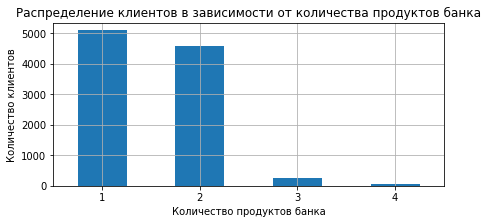

In [32]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['products'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от количества продуктов банка'
)

# Настраиваем оформление графика
plt.xlabel('Количество продуктов банка')
plt.ylabel('Количество клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Из категорий по количеству продуктов две значительно преобладают — теперь это хорошо видно.

---

### Непрерывные числовые данные

Теперь посмотрим на данные кредитного рейтинга клиента `score` и его баланса на счёте `balance`. Значения в них относятся к непрерывным вещественным данным.

Начнём с баланса — при знакомстве с подобными данными вначале стоит оценить статические показатели. Для этого используем метод `describe()`:

In [33]:
# Изучаем статистические показатели столбца balance
print('Статистические показатели столбца balance:')
df['balance'].describe()

Статистические показатели столбца balance:


count      6383.000000
mean     119827.493793
std       30095.056462
min        3768.690000
25%      100181.975000
50%      119839.690000
75%      139512.290000
max      250898.090000
Name: balance, dtype: float64

Можно предположить, что данные баланса имеют распределение, близкое к нормальному. Об этом говорит близость среднего и медианного значений. Однако значение стандартного отклонения довольно высокое — 30095.06, и при среднем 119827.49 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это и построим гистограмму распределения значений и диаграмму размаха для столбца с балансом.

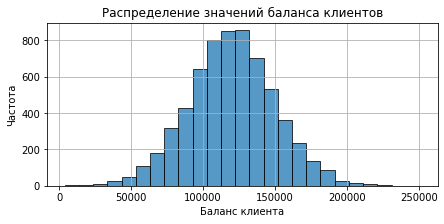

In [34]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['balance'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=25, # Устанавливаем количество корзин - всего 25
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений баланса клиентов')
plt.xlabel('Баланс клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

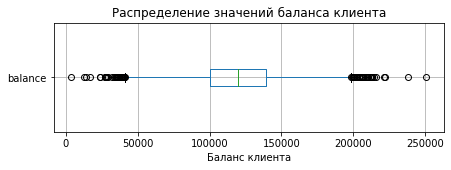

In [35]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 2))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='balance', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений баланса клиента')
plt.xlabel('Баланс клиента')

# Выводим график
plt.show()

Распределение данных действительно выглядит нормальным, однако характеризуется широким разбросом и «хвостами» как в левой, так и в правой части гистограммы. Такие низкие и высокие значения можно отнести к выбросам. Однако сами значения, как минимальные, так и максимальные, не выглядят ошибкой, и такой баланс у клиента вполне допустим. Поэтому при анализе данных их оставим.

Теперь изучим распределение значений в столбце `score`:

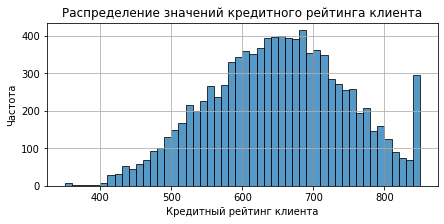

In [36]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['score'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений кредитного рейтинга клиента')
plt.xlabel('Кредитный рейтинг клиента')
plt.ylabel('Частота')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

На гистограмме видно, что распределение значений в столбце `score` приближается к нормальному, но резко увеличивается количество высоких значений, близких к 850. Такой пик может означать, что 850 — это значение-индикатор, которое отражает пропуски. Например, у таких клиентов может не быть кредитного рейтинга, так как ранее они не оформляли кредиты. Может быть и другое объяснение. Допустим, кредитный рейтинг клиента составляет больше 850. Если значение 850 является максимальным, то всем клиентам с рейтингом выше может присваиваться значение 850.

Проверим эту особенность данных отдельно и изучим распределение данных для значений рейтинга от 840 до 850:

In [37]:
# Проверяем распределение данных по значениям столбца score 840 и выше
print('Распределение данных по значениям столбца score 840 и выше:')
df.loc[df['score'] >= 840]['score'].value_counts()

Распределение данных по значениям столбца score 840 и выше:


850    233
841     12
849      8
842      7
844      7
845      6
847      6
840      5
846      5
848      5
843      2
Name: score, dtype: int64

Действительно, данных с рейтингом 850 значительно больше, чем с рейтингом от 840 до 849. Это может подтвердить одну из предложенных гипотез.

---

### Бинарные признаки и категориальные данные

Изучение бинарных признаков и категориальных данных похоже на изучение дискретных числовых данных с небольшим количеством значений. Для бинарных признаков важно оценить, как распределяются клиенты между признаками, а для категориальных данных — убедиться, что в них нет ошибок, а также проверить распределение значений по категориям.

При исследовании таких данных можно использовать метод `value_counts()` с аргументом `normalize=True`, чтобы сравнить доли значений. Изучим значения в столбцах с бинарными признаками, применив метод `value_counts()` для каждого столбца в цикле:

In [38]:
# Проверяем распределение данных по значениям в столбце
for column in ['credit_card','loyalty','churn']:
    print(f'Распределение данных по значениям столбца {column}:')
    print(df[column].value_counts(normalize=True))
    print()

Распределение данных по значениям столбца credit_card:
1    0.7055
0    0.2945
Name: credit_card, dtype: float64

Распределение данных по значениям столбца loyalty:
1    0.5151
0    0.4849
Name: loyalty, dtype: float64

Распределение данных по значениям столбца churn:
0    0.7963
1    0.2037
Name: churn, dtype: float64



Доля нелояльных клиентов, которые покинули банк, из столбца `churn` составляет около 20%, а доля клиентов без кредитных карт из столбца `credit_card` — около 30%. Распределение данных по уникальным значениям столбца `loyalty` примерно равно — 51% к 49%. Так соотносятся клиенты, которые участвуют в программах лояльности банка, с теми, кто предпочитает в них не участвовать.

Результаты `value_counts()` можно также визуализировать с помощью столбчатой диаграммы. Посмотрим на распределение клиентов по значениям в столбцах с полом клиента и городом:

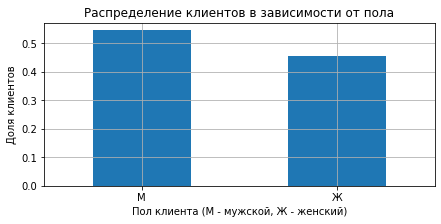

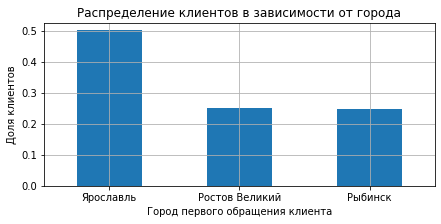

In [39]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['gender'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика — столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от пола'
)

# Настраиваем оформление графика
plt.xlabel('Пол клиента (М - мужской, Ж - женский)')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['city'].value_counts(normalize=True).plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение клиентов в зависимости от города'
)

# Настраиваем оформление графика
plt.xlabel('Город первого обращения клиента')
plt.ylabel('Доля клиентов')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

Судя по диаграммам, примерно 55% клиентов — женщины. Половина клиентов представляют Ярославль, а остальная половина — Ростов Великий и Рыбинск примерно поровну.

In [40]:
!pip install phik

---

Используя код этого блока, самостоятельно изучите данные в остальных столбцах.

---

Для самостоятельного изучения по аналогии с примерами из урока (value_counts(), describe(), гистограммы, boxplot, группировки при необходимости) рассмотрим следующие признаки:

- `age` — возраст клиента  
- `estimated_salary` — заработная плата клиента  
- `last_name` — фамилия клиента  
- `first_name` — имя клиента  
- `score` — баллы кредитного скоринга (в том числе гистограмма с `bins=50` и проверка пика около 850)


In [41]:
# Проверяем распределение данных по значениям столбца age
pd.set_option('display.max_rows', None)
print('Распределение данных по значениям столбца age:')
df['age'].value_counts()

Распределение данных по значениям столбца age:


37    478
38    477
35    474
36    456
34    447
33    442
40    432
39    423
32    418
31    404
41    366
29    348
30    327
42    321
43    297
28    273
44    257
45    229
46    226
27    209
26    200
47    175
48    168
25    154
49    147
50    134
24    132
51    119
52    102
23     99
22     84
54     84
55     82
57     75
53     74
56     70
58     67
59     62
60     62
61     53
21     53
62     52
63     40
20     40
67     37
64     37
66     35
71     27
19     27
18     22
69     22
72     21
68     19
65     18
74     18
70     18
73     13
76     11
77     10
75      9
78      5
79      4
81      4
80      3
84      2
92      2
88      1
82      1
85      1
83      1
Name: age, dtype: int64

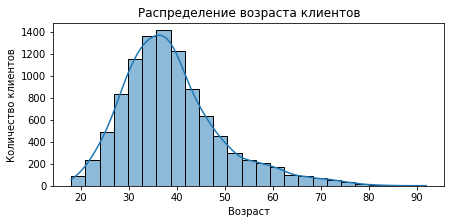

In [42]:
plt.figure(figsize=(7, 3))

sns.histplot(
    data=df,
    x='age',
    bins=25,
    kde=True,    
    edgecolor='black'
)

plt.title('Распределение возраста клиентов')
plt.xlabel('Возраст')
plt.ylabel('Количество клиентов')
plt.show()

- Возраст клиентов в выборке сосредоточен в диапазоне примерно от 30 до 45 лет: наиболее часто встречаются значения 33–41 года, каждое — у нескольких сотен клиентов.
- Молодёжи до 25 лет и людей старше 60 существенно меньше, их доля постепенно снижается по мере удаления от этого диапазона.
- Очень низкие и очень высокие возраста (18 лет и 80+ лет) встречаются единично и выглядят как редкие случаи.
- При этом распределение слегка смещено влево: пик приходится на клиентов среднего возраста, а доля более пожилых (старше 60–65 лет) постепенно снижается. 

In [43]:
print('Распределение клиентов по значениям столбца age:')
df.groupby('age')['products'].nunique() 

Распределение клиентов по значениям столбца age:


age
18    2
19    2
20    2
21    3
22    3
23    2
24    3
25    3
26    3
27    3
28    3
29    4
30    4
31    4
32    4
33    3
34    4
35    4
36    3
37    4
38    4
39    4
40    4
41    4
42    4
43    4
44    4
45    4
46    4
47    4
48    4
49    4
50    4
51    4
52    4
53    4
54    3
55    4
56    3
57    4
58    4
59    2
60    4
61    4
62    3
63    3
64    3
65    3
66    2
67    3
68    3
69    3
70    3
71    3
72    2
73    2
74    2
75    2
76    2
77    3
78    2
79    2
80    2
81    2
82    1
83    1
84    1
85    1
88    1
92    2
Name: products, dtype: int64

Этот вывод показывает, что практически в каждом возрасте у клиентов встречается от 2 до 4 разных значений признака `products`, то есть люди одного возраста могут иметь разное количество продуктов банка. Это говорит о том, что возраст сам по себе не «жёстко» фиксирует количество продуктов: внутри каждой возрастной группы есть вариативность по продуктовой активности.

In [44]:
df['estimated_salary'].max()

199992.48

In [45]:
bins = [0, 50000, 100000, 150000, df['estimated_salary'].max()]
labels = ['до 50k', '50–100k', '100–150k', '150–200k']

df['salary_group'] = pd.cut(
        df['estimated_salary'], 
        bins=bins,
        labels=labels,
        include_lowest=True)

print(df['salary_group'].value_counts(normalize=True))

100–150k    0.2555
50–100k     0.2537
150–200k    0.2455
до 50k      0.2453
Name: salary_group, dtype: float64


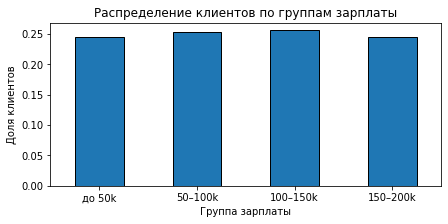

In [46]:
salary_dist = df['salary_group'].value_counts(normalize=True).sort_index()

plt.figure(figsize=(7, 3))
salary_dist.plot(
    kind='bar',
    rot=0,
    edgecolor='black'
)

plt.title('Распределение клиентов по группам зарплаты')
plt.xlabel('Группа зарплаты')
plt.ylabel('Доля клиентов')
plt.show()

Распределение клиентов по диапазонам зарплаты получилось достаточно равномерным: каждая группа содержит примерно по четверти выборки. Немного больше клиентов в сегменте 100–150k (около 25.5%) и 50–100k (около 25.4%), чуть меньше — в группах до 50k и 150–200k (по ~24.5%), то есть явного перекоса в сторону очень низких или очень высоких зарплат нет.

In [47]:
print('Статистические показатели столбца estimated_salary:')
df['estimated_salary'].describe()

Статистические показатели столбца estimated_salary:


count     10000.000000
mean     100090.239881
std       57510.492818
min          11.580000
25%       51002.110000
50%      100193.915000
75%      149388.247500
max      199992.480000
Name: estimated_salary, dtype: float64

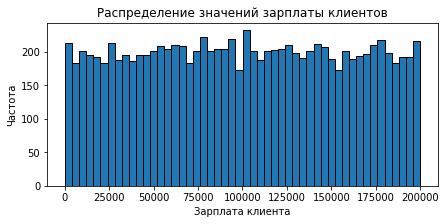

In [48]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['estimated_salary'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50, # Устанавливаем количество корзин - всего 25
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений зарплаты клиентов')
plt.xlabel('Зарплата клиента')
plt.ylabel('Частота')

# Выводим график
plt.show()

Зарплата клиентов распределена примерно симметрично вокруг среднего: среднее и медиана почти совпадают (≈100 тысяч), что говорит об отсутствии сильного перекоса. Большинство клиентов зарабатывают в диапазоне примерно от 51 до 149 тысяч (межквартильный размах), при этом встречаются как очень низкие значения (около 10), так и близкие к 200 тысячам, то есть разброс доходов довольно велик.

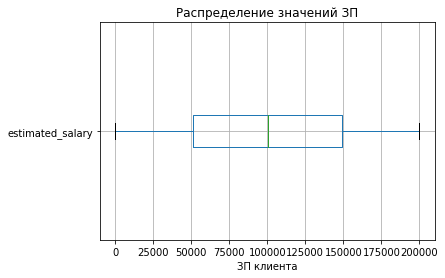

In [49]:
# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='estimated_salary', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений ЗП')
plt.xlabel('ЗП клиента')

# Выводим график
plt.show() 

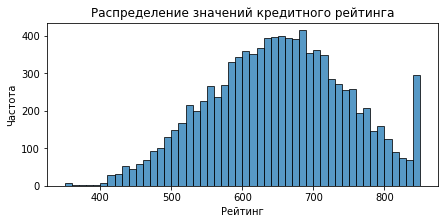

In [50]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(7, 3))

# Строим гистограмму с помощью pandas через plot(kind='hist')
df['score'].plot(
                kind='hist', # Тип графика - гистограмма
                bins=50,
                alpha=0.75,
                edgecolor='black',
                rot=0, # Градус вращения подписи по оси Х
)

# Настраиваем оформление графика
plt.title('Распределение значений кредитного рейтинга')
plt.xlabel('Рейтинг')
plt.ylabel('Частота')

# Выводим график
plt.show()

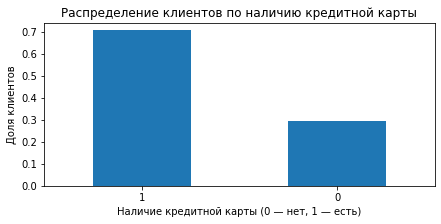

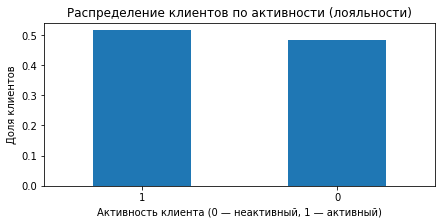

In [51]:
# Кредитные карты
plt.figure(figsize=(7, 3))

df['credit_card'].value_counts(normalize=True).plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Распределение клиентов по наличию кредитной карты'
)

plt.xlabel('Наличие кредитной карты (0 — нет, 1 — есть)')
plt.ylabel('Доля клиентов')
plt.show()

# Лояльность
plt.figure(figsize=(7, 3))

df['loyalty'].value_counts(normalize=True).plot(
    kind='bar',
    rot=0,
    legend=False,
    title='Распределение клиентов по активности (лояльности)'
)

plt.xlabel('Активность клиента (0 — неактивный, 1 — активный)')
plt.ylabel('Доля клиентов')
plt.show()

Доля клиентов с кредитной картой значительно выше, чем без неё: большинство пользователей банка имеют кредитную карту. При этом активных (лояльных) клиентов лишь немного больше половины, то есть заметная часть базы считается неактивной, несмотря на схожий доступ к продуктам банка.

interval columns not set, guessing: ['age', 'estimated_salary', 'objects', 'products', 'balance', 'score', 'credit_card', 'loyalty', 'churn']


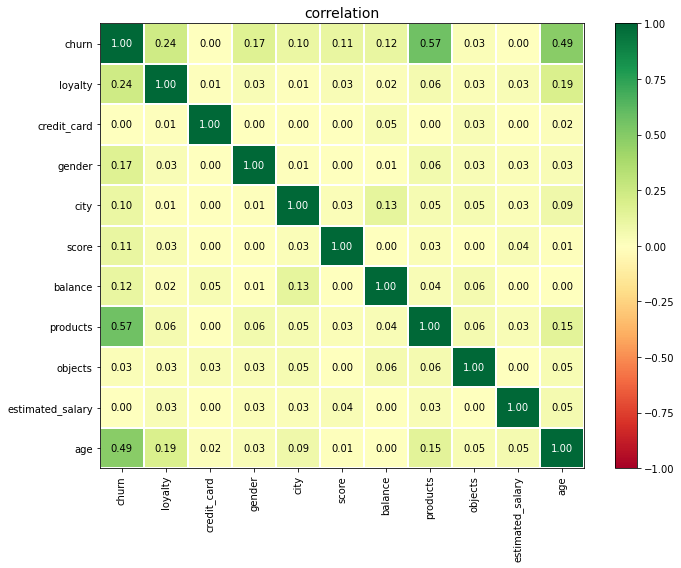

In [52]:
from phik.report import plot_correlation_matrix

# 1. Оставим только нужные столбцы
cols = ['age', 'estimated_salary', 'objects', 'products',
        'balance', 'score', 'city', 'gender',
        'credit_card', 'loyalty', 'churn']

df_corr = df[cols]

# 2. Строим матрицу корреляций phi_k
phik_matrix = df_corr.phik_matrix()

# 3. Визуализируем
plot_correlation_matrix(
    phik_matrix.values,
    x_labels=phik_matrix.columns,
    y_labels=phik_matrix.index,
    figsize=(10, 8)
)


- Клиенты с большим числом продуктов заметно чаще уходят: связь между количеством продуктов и оттоком самая сильная (phi_k ≈ 0.57).
- Отток выше среди более возрастных клиентов: возраст и churn связаны достаточно сильно (phi_k ≈ 0.49).

- Активные (лояльные) клиенты уходят реже: участие в программе лояльности умеренно связано с меньшим оттоком (phi_k ≈ 0.24).
- Зарплата, наличие кредитной карты, город, скоринговый балл и количество объектов собственности почти не влияют на отток: их корреляции с churn близки к нулю.
